In [ ]:
import requests
import pandas as pd

headers = {"authorization": f"Apikey"}

def obtener_datos(moneda, simbolo):
    url = "https://min-api.cryptocompare.com/data/v2/histoday"
    params = {"fsym": simbolo, "tsym": "USD", "limit": 2000}  # hasta ~5 años
    response = requests.get(url, headers=headers, params=params)

    if response.status_code != 200:
        print(f" Error con {moneda}: {response.status_code}")
        return pd.DataFrame()

    data = response.json()
    df = pd.DataFrame(data["Data"]["Data"])
    df["time"] = pd.to_datetime(df["time"], unit="s")
    df = df[["time", "open", "high", "low", "close", "volumeto"]]
    df["coin"] = moneda
    return df

monedas = {"bitcoin": "BTC", "ethereum": "ETH", "solana": "SOL"}
dfs = []

for nombre, simbolo in monedas.items():
    print(f"📥 Descargando datos de {nombre}...")
    df_temp = obtener_datos(nombre, simbolo)
    if not df_temp.empty:
        dfs.append(df_temp)

if dfs:
    df_final = pd.concat(dfs)
    df_final.to_csv("criptomonedas_crypto_compare.csv", index=False)
    print("✅ Datos guardados en criptomonedas_crypto_compare.csv")
else:
    print("⚠️ No se pudo obtener ningún dato.")




📥 Descargando datos de bitcoin...
📥 Descargando datos de ethereum...
📥 Descargando datos de solana...
✅ Datos guardados en criptomonedas_crypto_compare.csv


In [ ]:
import pandas as pd

df = pd.read_csv("criptomonedas_crypto_compare.csv")
df.head()


,time,open,high,low,close,volumeto,coin
0,2020-05-15,9793.19,9841.71,9149.13,9311.69,7.989309e+08,bitcoin
1,2020-05-16,9311.69,9584.90,9224.32,9387.08,3.482624e+08,bitcoin
2,2020-05-17,9387.08,9885.55,9334.23,9670.56,5.058349e+08,bitcoin
3,2020-05-18,9670.56,9943.74,9476.37,9722.73,6.062352e+08,bitcoin
4,2020-05-19,9722.73,9890.69,9471.96,9780.20,5.876600e+08,bitcoin


In [ ]:
df = pd.read_csv("criptomonedas_crypto_compare.csv")

# Eliminar duplicados
df.drop_duplicates(inplace=True)

# Manejo de valores nulos
df.dropna(inplace=True)

# Verificar tipos de datos
df["time"] = pd.to_datetime(df["time"])

# Ordenar por fecha
df.sort_values(by=["coin", "time"], inplace=True)

# Guardar dataset limpio
df.to_csv("criptomonedas_limpias.csv", index=False)
print("✅ Datos limpios y listos para análisis.")


✅ Datos limpios y listos para análisis.


            open                                                             \
           count          mean           std        min       25%       50%   
coin                                                                          
bitcoin   2001.0  48548.213018  30341.707353  8718.4900  24757.56  41474.72   
ethereum  2001.0   2269.627461   1104.821403   194.7100   1588.56   2193.78   
solana    2001.0     86.288733     74.579763     0.5473     20.82     51.66   

                                 high                ...     close             \
               75%        max   count          mean  ...       75%        max   
coin                                                 ...                        
bitcoin   64119.34  124723.00  2001.0  49545.121554  ...  64156.30  124723.00   
ethereum   3118.76    4830.60  2001.0   2332.941644  ...   3123.72    4830.60   
solana      151.05     261.87  2001.0     89.701772  ...    151.17     261.87   

         volumeto                     

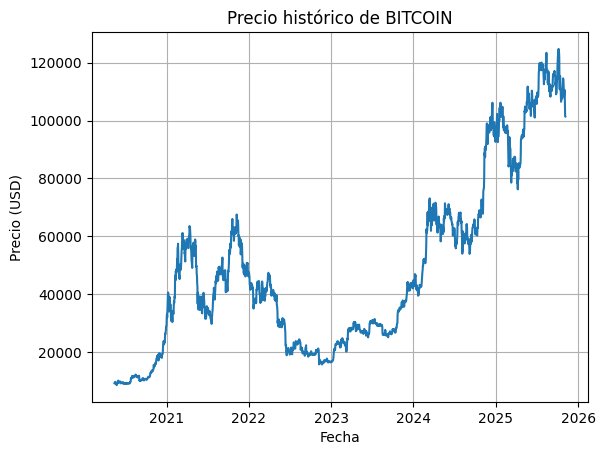

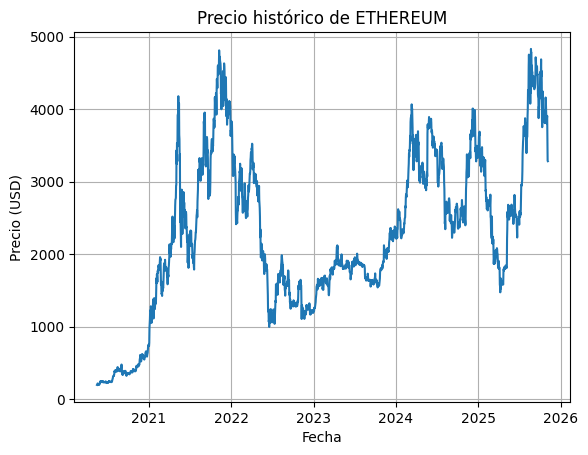

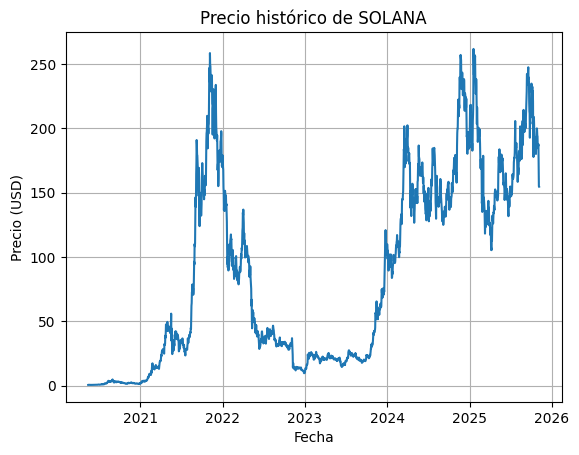

In [ ]:
# Estadísticas básicas
estadisticas = df.groupby("coin")[["open", "high", "low", "close", "volumeto"]].describe()
print(estadisticas)

# Promedios por moneda
promedios = df.groupby("coin")[["open", "close", "volumeto"]].mean()
print("\nPromedios generales:\n", promedios)

# Gráficos simples
import matplotlib.pyplot as plt
for coin in df["coin"].unique():
    sub = df[df["coin"] == coin]
    plt.figure()
    plt.plot(sub["time"], sub["close"])
    plt.title(f"Precio histórico de {coin.upper()}")
    plt.xlabel("Fecha")
    plt.ylabel("Precio (USD)")
    plt.grid()
    plt.show()


✅ Datos cargados correctamente.
✅ Datos listos para clusterización (Shape: (6003, 5))

--- K-Means Clustering ---


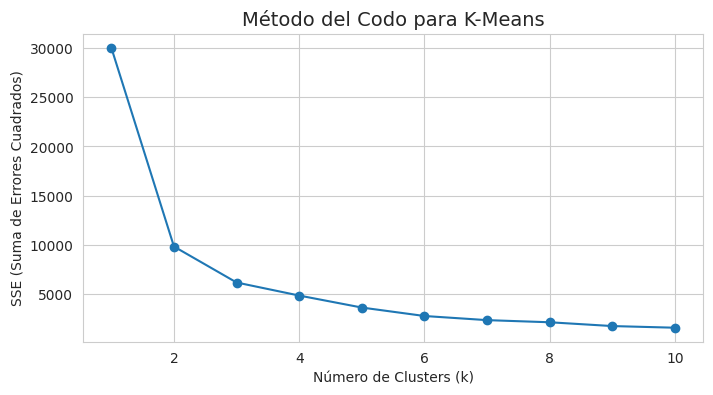

Puntuación de Silueta (K-Means, K=3): 0.6628


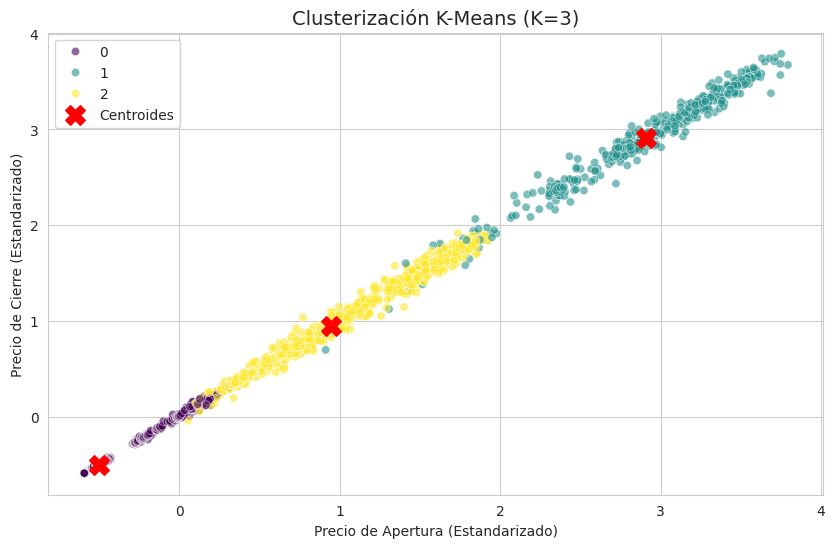


--- DBSCAN Clustering ---
Clusters encontrados (DBSCAN): 1
Puntos de Ruido (-1) (DBSCAN): 39


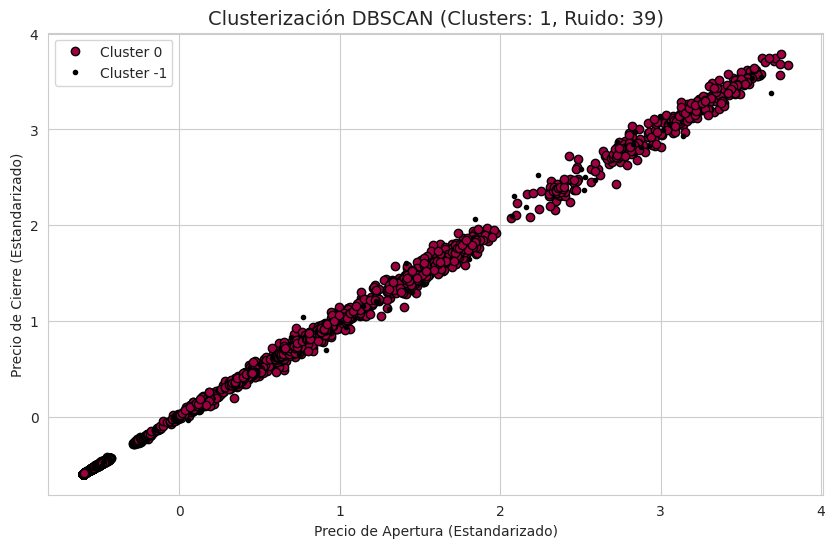


--- Clusterización Jerárquica ---


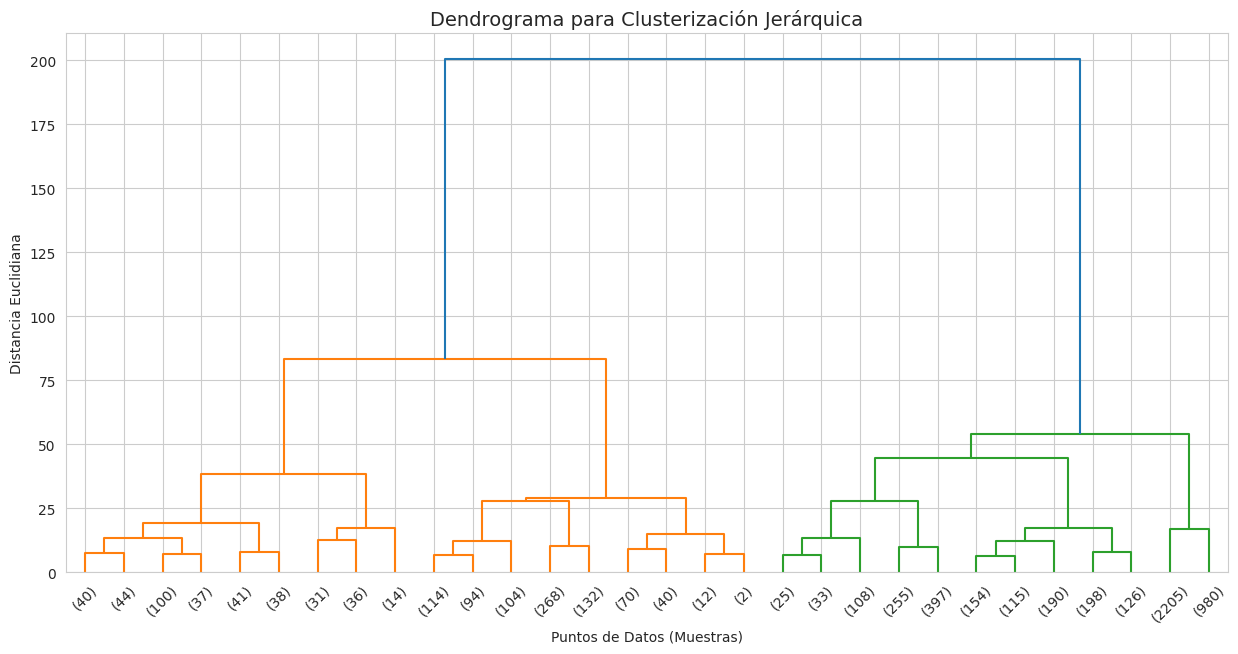

Puntuación de Silueta (Jerárquica, N=3): 0.6703


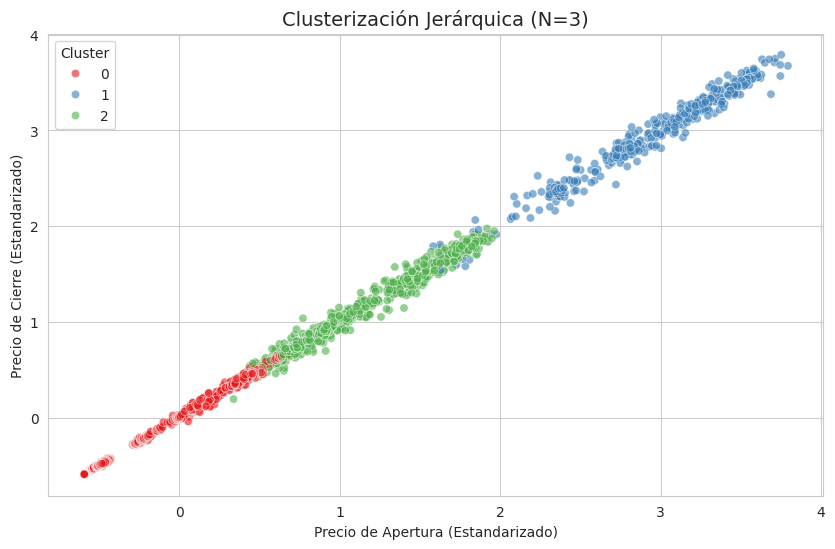


--- Resumen de Clusters K-Means por Moneda ---
       coin  cluster_kmeans  Count
0   bitcoin               0    457
1   bitcoin               1    391
2   bitcoin               2   1153
3  ethereum               0   1999
4  ethereum               2      2
5    solana               0   2001

--- Resumen de Clusters Jerárquicos por Moneda ---
       coin  cluster_agglo  Count
0   bitcoin              0    785
1   bitcoin              1    381
2   bitcoin              2    835
3  ethereum              0   2000
4  ethereum              2      1
5    solana              0   2001


In [6]:
# SCRIPT DE CLUSTERIZACIÓN PARA DATOS DE CRIPTOMONEDAS

# 1. Instalar librerías adicionales si es necesario (generalmente no se requiere en Colab)
# !pip install scikit-learn matplotlib seaborn

# 2. Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from itertools import cycle, islice

# Configuración para visualización (opcional)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

# --- Carga y Preparación de Datos ---

# 3. Cargar el archivo CSV
# Asegúrate de que el archivo 'base_datos_criptomonedas.csv'
# se haya subido a tu sesión de Google Colab antes de ejecutar.
file_path = 'criptomonedas_limpias.csv' # Modified file path
try:
    df = pd.read_csv(file_path)
    print("✅ Datos cargados correctamente.")
except FileNotFoundError:
    print(f"❌ Error: Archivo no encontrado en la ruta: {file_path}")
    # Puedes intentar montar Google Drive si el archivo está allí
    # from google.colab import drive
    # drive.mount('/content/drive')
    # file_path = '/content/drive/MyDrive/ruta/a/base_datos_criptomonedas.csv'
    # df = pd.read_csv(file_path)
    # return # Terminar si no se carga
    exit()

# 4. Preprocesamiento: Seleccionar características y escalar
# Se usarán las columnas numéricas de precios y volumen
features = ['open', 'high', 'low', 'close', 'volumeto']
X = df[features].copy()
coin_names = df['coin'] # Mantener el nombre de la moneda para el análisis

# Estandarización de los datos (fundamental para K-Means y DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(f"✅ Datos listos para clusterización (Shape: {X_scaled.shape})")

# --- 5. TÉCNICA 1: K-MEANS (Clusterización Particionante) ---

print("\n--- K-Means Clustering ---")

# 5.1. Búsqueda del número óptimo de clusters (Método del Codo)
sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    sse[k] = kmeans.inertia_ # Suma de errores cuadrados

# 5.2. Visualización del Método del Codo
plt.figure(figsize=(8, 4))
plt.plot(list(sse.keys()), list(sse.values()), marker='o')
plt.title('Método del Codo para K-Means', fontsize=14)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('SSE (Suma de Errores Cuadrados)')
plt.grid(True)
plt.show()

# 5.3. Aplicar K-Means con un número K óptimo (ejemplo: K=3)
# Ajusta K según el gráfico del codo. Aquí se usa un valor por defecto.
K_OPTIMO = 3
kmeans_model = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init='auto')
clusters_kmeans = kmeans_model.fit_predict(X_scaled)
df['cluster_kmeans'] = clusters_kmeans

# 5.4. Evaluar el modelo (Puntuación de Silueta)
score_kmeans = silhouette_score(X_scaled, clusters_kmeans)
print(f"Puntuación de Silueta (K-Means, K={K_OPTIMO}): {score_kmeans:.4f}")

# 5.5. Visualización del Cluster K-Means (usando dos características escaladas)
plt.figure(figsize=(10, 6))
# Usaremos las dos primeras componentes principales si fuera necesario,
# pero por simplicidad se usan 'open' y 'close' estandarizadas.
sns.scatterplot(
    x=X_scaled_df['open'],
    y=X_scaled_df['close'],
    hue=df['cluster_kmeans'],
    palette='viridis',
    legend='full',
    alpha=0.6
)
# Graficar centroides
centers = scaler.inverse_transform(kmeans_model.cluster_centers_)
# Como el scatterplot usa datos escalados, graficamos los centroides escalados
centers_scaled = kmeans_model.cluster_centers_
plt.scatter(
    centers_scaled[:, features.index('open')],
    centers_scaled[:, features.index('close')],
    marker='X',
    s=200,
    color='red',
    label='Centroides'
)
plt.title(f'Clusterización K-Means (K={K_OPTIMO})', fontsize=14)
plt.xlabel('Precio de Apertura (Estandarizado)')
plt.ylabel('Precio de Cierre (Estandarizado)')
plt.legend()
plt.show()


# --- 6. TÉCNICA 2: DBSCAN (Clusterización Basada en Densidad) ---

print("\n--- DBSCAN Clustering ---")

# 6.1. Aplicar DBSCAN
# Los parámetros eps y min_samples son clave y dependen del dataset.
# Se usan valores iniciales. Puede requerir ajuste.
dbscan_model = DBSCAN(eps=0.5, min_samples=5)
clusters_dbscan = dbscan_model.fit_predict(X_scaled)
df['cluster_dbscan'] = clusters_dbscan
n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = list(clusters_dbscan).count(-1)

print(f"Clusters encontrados (DBSCAN): {n_clusters_dbscan}")
print(f"Puntos de Ruido (-1) (DBSCAN): {n_noise}")

# 6.2. Visualización del Cluster DBSCAN
plt.figure(figsize=(10, 6))
# Se usa 'open' y 'close' estandarizadas para la visualización
# Asignar un color a cada cluster, incluido el ruido (-1)
unique_labels = set(clusters_dbscan)
# Handle case where there's only one cluster or noise
if len(unique_labels) == 1 and list(unique_labels)[0] == -1:
    colors = ['k'] # Noise points in black
elif len(unique_labels) == 1:
    colors = ['b'] # Single cluster in blue
else:
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Puntos de ruido en negro
        col_face = 'k'
        marker = '.'
    else:
        col_face = col
        marker = 'o'

    class_member_mask = (clusters_dbscan == k)
    xy = X_scaled[class_member_mask]

    # Handle the case where there's only one cluster or noise
    if len(unique_labels) == 1:
         plt.plot(xy[:, features.index('open')], xy[:, features.index('close')], marker, color=col,
                 markeredgecolor='k', markersize=6, label=f'Cluster {k}')
    else:
         plt.plot(xy[:, features.index('open')], xy[:, features.index('close')], marker, markerfacecolor=col_face,
                 markeredgecolor='k', markersize=6, label=f'Cluster {k}')


plt.title(f'Clusterización DBSCAN (Clusters: {n_clusters_dbscan}, Ruido: {n_noise})', fontsize=14)
plt.xlabel('Precio de Apertura (Estandarizado)')
plt.ylabel('Precio de Cierre (Estandarizado)')
plt.legend()
plt.show()


# --- 7. TÉCNICA 3: CLUSTERIZACIÓN JERÁRQUICA (Agglomerative) ---

print("\n--- Clusterización Jerárquica ---")

# 7.1. Generar el enlace (Linkage Matrix) para el dendrograma
# Se utiliza el método 'ward' para minimizar la varianza de los clusters fusionados.
linked = linkage(X_scaled, method='ward')

# 7.2. Visualización del Dendrograma
plt.figure(figsize=(15, 7))
dendrogram(
    linked,
    orientation='top',
    labels=coin_names.to_list(),
    truncate_mode='lastp',  # Muestra solo los últimos 'p' clusters fusionados
    p=30, # Ajusta 'p' para no sobrecargar la gráfica
    show_leaf_counts=True,
    distance_sort='descending'
)
plt.title('Dendrograma para Clusterización Jerárquica', fontsize=14)
plt.xlabel('Puntos de Datos (Muestras)')
plt.ylabel('Distancia Euclidiana')
plt.show()

# 7.3. Aplicar Clusterización Jerárquica con número de clusters fijos (ejemplo: N=3)
# El número de clusters se puede determinar cortando el dendrograma.
N_CLUSTERS_JERARQUICO = 3
agglo_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_JERARQUICO, linkage='ward')
clusters_agglo = agglo_model.fit_predict(X_scaled)
df['cluster_agglo'] = clusters_agglo

# 7.4. Evaluar el modelo (Puntuación de Silueta)
score_agglo = silhouette_score(X_scaled, clusters_agglo)
print(f"Puntuación de Silueta (Jerárquica, N={N_CLUSTERS_JERARQUICO}): {score_agglo:.4f}")

# 7.5. Visualización del Cluster Jerárquico
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_scaled_df['open'],
    y=X_scaled_df['close'],
    hue=df['cluster_agglo'],
    palette='Set1',
    legend='full',
    alpha=0.6
)
plt.title(f'Clusterización Jerárquica (N={N_CLUSTERS_JERARQUICO})', fontsize=14)
plt.xlabel('Precio de Apertura (Estandarizado)')
plt.ylabel('Precio de Cierre (Estandarizado)')
plt.legend(title='Cluster')
plt.show()

# 8. Mostrar resumen de los clusters por moneda (solo para el análisis)
print("\n--- Resumen de Clusters K-Means por Moneda ---")
cluster_summary = df.groupby(['coin', 'cluster_kmeans']).size().reset_index(name='Count')
print(cluster_summary)

print("\n--- Resumen de Clusters Jerárquicos por Moneda ---")
cluster_summary_agglo = df.groupby(['coin', 'cluster_agglo']).size().reset_index(name='Count')
print(cluster_summary_agglo)